In [50]:
import os
import pandas as pd

# Jeśli bieżący folder to 'dane', pliki są tu na miejscu ('.'). 
# Jeśli bieżący folder to 'Big-bank', pliki są w podfolderze 'dane'.
base_dir = "." if os.path.basename(os.getcwd()) == "dane" else "dane"

files = {
    'ING': 'ing_pb_d.csv',
    'MBANK': 'mbk_pb_d.csv',
    'PEKAO': 'peo_pb_d.csv',
    'PKO': 'pko_pb_d.csv',
    'SANTANDER': 'san_pb_d.csv'
}

data_frames = {}

for bank, filename in files.items():
    filepath = os.path.join(base_dir, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Nie znaleziono pliku: {filepath} (katalog: {os.getcwd()})")
    
    df = pd.read_csv(filepath)
    df.columns = [c.strip().capitalize() for c in df.columns]
    date_col = 'Data' if 'Data' in df.columns else 'Date'
    val_col = 'Zamkniecie' if 'Zamkniecie' in df.columns else ('Close' if 'Close' in df.columns else df.columns[1])
    
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col)
    df = df.set_index(date_col)
    
    data_frames[bank] = df[val_col]

df_combined = pd.DataFrame(data_frames).dropna()

print(f"Zakres wspólny dzienny: od {df_combined.index.min().date()} do {df_combined.index.max().date()}")
print(f"Liczba dni sesyjnych: {len(df_combined)}")

df_weekly = df_combined.resample('W-FRI').last().dropna()
df_normalized = df_weekly / df_weekly.median()

output_path = os.path.join(base_dir, "banki_pbv_tygodniowe_znormalizowane.csv")
df_normalized.to_csv(output_path)
print(f"\nGotowe. Zapisano '{output_path}'")

Zakres wspólny dzienny: od 2014-12-03 do 2026-09-16
Liczba dni sesyjnych: 2643

Gotowe. Zapisano './banki_pbv_tygodniowe_znormalizowane.csv'


In [51]:
import os
import numpy as np
import pandas as pd

if os.path.exists('wig20_d.csv'):
    input_path = 'wig20_d.csv'
    output_path = 'zmiennosc_d.csv'
elif os.path.exists(os.path.join('dane', 'wig20_d.csv')):
    input_path = os.path.join('dane', 'wig20_d.csv')
    output_path = os.path.join('dane', 'zmiennosc_d.csv')
else:
    raise FileNotFoundError(f"Nie znaleziono pliku. Aktualny katalog: {os.getcwd()}, zawartość: {os.listdir('.')}")
# 1. Wczytanie danych WIG20
df = pd.read_csv(input_path)

# Standaryzacja nazw kolumn
df.columns = [c.strip().capitalize() for c in df.columns]
date_col = 'Data' if 'Data' in df.columns else 'Date'
close_col = 'Zamkniecie' if 'Zamkniecie' in df.columns else 'Close'

# Konwersja daty i sortowanie chronologiczne
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(by=date_col).reset_index(drop=True)

# 2. Obliczenie logarytmicznych stóp zwrotu
# r_t = ln(P_t / P_{t-1})
df['Log_Returns'] = np.log(df[close_col] / df[close_col].shift(1))

# 3. Obliczenie kroczącej zmienności zrealizowanej (okno 20 dni sesyjnych)
# sqrt(252) zannualizuje wartość (standard w analizie szeregów finansowych)
WINDOW = 20
df['Zmiennosc'] = df['Log_Returns'].rolling(window=WINDOW).std() * np.sqrt(252)

# 4. Przygotowanie ramki wynikowej w formacie reszty plików (*_d.csv)
df_vol = df[[date_col, 'Zmiennosc']].dropna().copy()
df_vol.rename(columns={'Zmiennosc': 'Zamkniecie'}, inplace=True)

# 5. Zapis do pliku
df_vol.to_csv(output_path, index=False)
print(f"Zapisano pomyślnie: {output_path}")
print("\nPodgląd ostatnich 5 wierszy:")
print(df_vol.tail())

Zapisano pomyślnie: zmiennosc_d.csv

Podgląd ostatnich 5 wierszy:
           Data  Zamkniecie
8404 2026-09-10    0.152241
8405 2026-09-11    0.152742
8406 2026-09-14    0.147149
8407 2026-09-15    0.143391
8408 2026-09-16    0.139619


In [52]:
import os
import pandas as pd

base_dir = '.' if os.path.exists('wig20_d.csv') else ('dane' if os.path.exists('dane/wig20_d.csv') else '')
output_path = os.path.join(base_dir, 'wig_banki_d.csv') if base_dir else 'wig_banki_d.csv'

# Pliki 5 banków, które już masz
bank_files = [
    'pko_pb_d.csv',
    'peo_pb_d.csv',
    'san_pb_d.csv',
    'ing_pb_d.csv',
    'mbk_pb_d.csv'
]

dfs = []
for fname in bank_files:
    fpath = os.path.join(base_dir, fname) if base_dir else fname
    df = pd.read_csv(fpath, sep=None, engine='python')
    df.columns = [str(c).strip().lower() for c in df.columns]
    
    date_col = next((c for c in ['data', 'date', 'czas'] if c in df.columns), df.columns[0])
    val_col = next((c for c in ['zamkniecie', 'close', 'ostatnio'] if c in df.columns), df.columns[1])
    
    if df[val_col].dtype == object:
        df[val_col] = pd.to_numeric(df[val_col].astype(str).str.replace(',', '.'), errors='coerce')
        
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    s = df.dropna(subset=[date_col, val_col]).set_index(date_col)[val_col]
    dfs.append(s)

# Połączenie i wyliczenie indeksu ważonego (baza = 1000 pkt)
df_banks = pd.concat(dfs, axis=1, join='inner')

# Liczymy dzienne zmiany procentowe i średni zwrot sektora
returns = df_banks.pct_change().mean(axis=1).fillna(0)
synthetic_index = (1 + returns).cumprod() * 1000.0

# Zapis w standardowym formacie Stooq
df_out = pd.DataFrame({
    'Data': synthetic_index.index.strftime('%Y-%m-%d'),
    'Otwarcie': synthetic_index.values,
    'Najwyzszy': synthetic_index.values,
    'Najnizszy': synthetic_index.values,
    'Zamkniecie': synthetic_index.values,
    'Wolumen': 0
})

df_out.to_csv(output_path, index=False)
print(f"Utworzono syntetyczny indeks WIG-Banki: {output_path}")
print(df_out.tail(3))

Utworzono syntetyczny indeks WIG-Banki: ./wig_banki_d.csv
            Data     Otwarcie    Najwyzszy    Najnizszy   Zamkniecie  Wolumen
2640  2026-09-14  2814.836053  2814.836053  2814.836053  2814.836053        0
2641  2026-09-15  2816.953860  2816.953860  2816.953860  2816.953860        0
2642  2026-09-16  2795.159168  2795.159168  2795.159168  2795.159168        0


In [53]:
import os
import csv
import pandas as pd

base_dir = '.' if os.path.exists('wig20_d.csv') else ('dane' if os.path.exists('dane/wig20_d.csv') else '')

all_files = {
    'pbv_pko': 'pko_pb_d.csv',
    'pbv_peo': 'peo_pb_d.csv',
    'pbv_san': 'san_pb_d.csv',
    'pbv_ing': 'ing_pb_d.csv',
    'pbv_mbk': 'mbk_pb_d.csv',
    'wibor_3m': 'plopln3m_d.csv',
    'rentownosc_10y': 'Obligacje_10y.csv',
    'eurpln': 'eurpln_d.csv',
    'wig20': 'wig20_d.csv',
    'zmiennosc': 'zmiennosc_d.csv',
    'wig_banki': 'wig_banki_d.csv'
}

data_dict = {}

for col_name, fname in all_files.items():
    fpath = os.path.join(base_dir, fname) if base_dir else fname
    
    try:
        df = pd.read_csv(fpath, sep=None, engine='python', quoting=csv.QUOTE_NONE, on_bad_lines='skip')
    except Exception:
        df = pd.read_csv(fpath, sep=',', quoting=csv.QUOTE_NONE, on_bad_lines='skip')
    
    df.columns = [str(c).replace('"', '').strip().lower() for c in df.columns]
    date_col = next((c for c in ['data', 'date', 'czas', 'time'] if c in df.columns), df.columns[0])
    val_col = next((c for c in ['zamkniecie', 'close', 'ostatnio', 'kurs', 'wartosc'] if c in df.columns), df.columns[1])
    
    if df[val_col].dtype == object:
        df[val_col] = df[val_col].astype(str).str.replace('"', '').str.replace(',', '.').str.strip()
        df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
        
    df[date_col] = pd.to_datetime(df[date_col].astype(str).str.replace('"', ''), errors='coerce')
    df = df.dropna(subset=[date_col, val_col]).sort_values(by=date_col).set_index(date_col)
    
    # Resampling tygodniowy
    data_dict[col_name] = df[val_col].resample('W-FRI').last()

# 1. Złączenie OUTER (żeby rzadkie dane nie wycięły reszty tygodni)
df_weekly = pd.DataFrame(data_dict)

# 2. Uzupełnienie luk w obligacjach/makro ostatnią znaną wartością (forward-fill)
df_weekly = df_weekly.ffill()

# 3. Usunięcie tylko tych wierszy z początku, gdzie któryś bank jeszcze nie istniał
df_weekly = df_weekly.dropna()

# 4. Normalizacja P/BV przez medianę
pbv_cols = ['pbv_pko', 'pbv_peo', 'pbv_san', 'pbv_ing', 'pbv_mbk']
df_weekly[pbv_cols] = df_weekly[pbv_cols] / df_weekly[pbv_cols].median()

# 5. Wyznaczenie target_y (kolejny tydzień)
df_weekly['target_y'] = (df_weekly['wig_banki'].shift(-1) > df_weekly['wig_banki']).astype(int)
df_final = df_weekly.iloc[:-1].drop(columns=['wig_banki'])

# 6. Zapis
out_path = os.path.join(base_dir, 'dataset_final.csv') if base_dir else 'dataset_final.csv'
df_final.to_csv(out_path)

print(f"Utworzono: {out_path}")
print(f"Liczba próbek tygodniowych: {len(df_final)} (powinno być ~50-52 na każdy rok)")

Utworzono: ./dataset_final.csv
Liczba próbek tygodniowych: 615 (powinno być ~50-52 na każdy rok)


In [55]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from iqm.qiskit_iqm import IQMProvider

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import rbf_kernel, pairwise_distances
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ==========================================
# 1. KONFIGURACJA I DANE
# ==========================================
def get_iqm_backend():
    env_path = "../iqm_token.env" if os.path.exists("../iqm_token.env") else "iqm_token.env"
    load_dotenv(env_path)
    server_url = os.getenv("SERVER")
    provider = IQMProvider(server_url)
    backend = provider.get_backend()
    print(f"Połączono z backendem: {backend.name}")
    return backend

def load_data(filepath, n_samples=None):
    df = pd.read_csv(filepath, index_col=0)
    X_raw = df.drop(columns=["target_y"]).values
    y = df["target_y"].values
    
    if n_samples:
        X_raw = X_raw[-n_samples:]
        y = y[-n_samples:]
        
    scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
    X_norm = scaler.fit_transform(X_raw)
    return X_norm, y

# ==========================================
# 2. GENERATOR OBWODÓW
# ==========================================
def build_base_ansatz(x, num_qubits=5):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)
    qc.cx(num_qubits - 1, 0)
    
    for i in range(num_qubits):
        qc.ry(x[(2 * i + 3) % 10], i)
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)
    return qc

def build_measurement_circuits(x, num_qubits=5):
    qc_x = build_base_ansatz(x, num_qubits)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    qc_y = build_base_ansatz(x, num_qubits)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    qc_z = build_base_ansatz(x, num_qubits)
    qc_z.measure_all()
    
    return qc_x, qc_y, qc_z

# ==========================================
# 3. SYMULACJA IDEALNA (BEZSZUMOWA)
# ==========================================
def compute_phi_simulator(X_norm, num_qubits=5):
    print(f"Uruchamianie idealnej symulacji dla {len(X_norm)} próbek...")
    estimator = StatevectorEstimator()
    
    # Tworzymy obserwable X_i, Y_i, Z_i dla każdego kubitu
    observables = []
    for q in range(num_qubits):
        for pauli in ['X', 'Y', 'Z']:
            label = ['I'] * num_qubits
            label[num_qubits - 1 - q] = pauli  # Odwrócenie indeksowania pod Qiskit
            observables.append(SparsePauliOp("".join(label)))
            
    Phi_sim = []
    for x in X_norm:
        qc = build_base_ansatz(x, num_qubits)
        pubs = [(qc, obs) for obs in observables]
        job = estimator.run(pubs)
        vals = [float(res.data.evs) for res in job.result()]
        Phi_sim.append(vals)
        
    return np.array(Phi_sim)

# ==========================================
# 4. FIZYCZNE WYKONANIE NA QPU ODRA
# ==========================================
def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits):
            expvals[q] += bits[q] * count
    return expvals / total_shots

def compute_phi_odra(backend, X_norm, num_qubits=5, shots=1024, batch_size=50):
    all_circuits = []
    for x in X_norm:
        all_circuits.extend(build_measurement_circuits(x, num_qubits))
        
    print(f"Transpilacja {len(all_circuits)} obwodów dla backendu {backend.name}...")
    transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
    
    print(f"Wysyłanie paczek (batch_size={batch_size}) na QPU Odra...")
    all_counts = []
    for i in range(0, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"  Paczka {i//batch_size + 1}/{(len(transpiled) - 1)//batch_size + 1}...")
        job = backend.run(batch, shots=shots)
        res = job.result()
        for j in range(len(batch)):
            all_counts.append(res.get_counts(j))
            
    Phi_odra = np.zeros((len(X_norm), num_qubits * 3))
    for i in range(len(X_norm)):
        exp_x = expectation_from_counts(all_counts[3 * i], num_qubits)
        exp_y = expectation_from_counts(all_counts[3 * i + 1], num_qubits)
        exp_z = expectation_from_counts(all_counts[3 * i + 2], num_qubits)
        
        # Format ułożenia identyczny z symulatorem: [X0, Y0, Z0, X1, Y1, Z1...]
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = exp_x[q]
            Phi_odra[i, 3 * q + 1] = exp_y[q]
            Phi_odra[i, 3 * q + 2] = exp_z[q]
            
    np.save("phi_odra_wig_banki.npy", Phi_odra)
    return Phi_odra

# ==========================================
# 5. EWALUACJA WALK-FORWARD (WSZYSTKIE MODELE)
# ==========================================
def evaluate_walk_forward(X_norm, Phi_sim, Phi_odra, y, train_window=52):
    n_samples = len(y)
    y_true = []
    preds_classical = []
    preds_sim = []
    preds_odra = []
    
    # Parametr gamma wyznaczany na rzutach symulatora
    dists = pairwise_distances(Phi_sim)
    med_dist = np.median(dists[dists > 0])
    gamma = 1.0 / (2.0 * (med_dist ** 2) + 1e-8)
    
    print("\nEwaluacja krocząca Out-Of-Sample...")
    for t in range(train_window, n_samples):
        y_tr = y[t - train_window : t]
        y_te = y[t]
        y_true.append(y_te)
        
        # A. Klasyczna Regresja Logistyczna (bez sztucznego balansowania wag)
        lr = LogisticRegression(C=1.0)
        lr.fit(X_norm[t - train_window : t], y_tr)
        preds_classical.append(lr.predict(X_norm[t : t + 1])[0])
        
        # B. PQK Symulator
        K_tr_sim = rbf_kernel(Phi_sim[t - train_window : t], Phi_sim[t - train_window : t], gamma=gamma)
        K_te_sim = rbf_kernel(Phi_sim[t : t + 1], Phi_sim[t - train_window : t], gamma=gamma)
        clf_sim = SVC(kernel="precomputed", C=5.0)
        clf_sim.fit(K_tr_sim, y_tr)
        preds_sim.append(clf_sim.predict(K_te_sim)[0])
        
        # C. PQK Odra QPU
        K_tr_odra = rbf_kernel(Phi_odra[t - train_window : t], Phi_odra[t - train_window : t], gamma=gamma)
        K_te_odra = rbf_kernel(Phi_odra[t : t + 1], Phi_odra[t - train_window : t], gamma=gamma)
        clf_odra = SVC(kernel="precomputed", C=5.0)
        clf_odra.fit(K_tr_odra, y_tr)
        preds_odra.append(clf_odra.predict(K_te_odra)[0])

    # Zestawienie wyników
    acc_base = max(np.mean(y_true), 1 - np.mean(y_true)) * 100
    acc_lr = accuracy_score(y_true, preds_classical) * 100
    acc_sim = accuracy_score(y_true, preds_sim) * 100
    acc_odra = accuracy_score(y_true, preds_odra) * 100
    
    fidelity_corr = np.mean([np.corrcoef(Phi_sim[i], Phi_odra[i])[0, 1] for i in range(n_samples)])
    
    print("\n" + "=" * 52)
    print("ZESTAWIENIE WYNIKÓW (WALK-FORWARD ACCURACY):")
    print(f"Liczba prognozowanych kroków: {len(y_true)}")
    print(f"Baseline (dominujący trend):   {acc_base:.2f}%")
    print(f"Regresja Logistyczna (klas.):  {acc_lr:.2f}%")
    print(f"PQK Symulator (analityczny):   {acc_sim:.2f}%")
    print(f"PQK Fizyczna Odra (QPU):       {acc_odra:.2f}%")
    print("-" * 52)
    print(f"Średnia korelacja rzutów Odra vs Symulator: {fidelity_corr:.4f}")
    print("=" * 52)

# ==========================================
# START
# ==========================================
if __name__ == "__main__":
    csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"
    
    # Dobierz liczbę próbek: None = pełen zbiór (615), int = np. ostatnie 50 próbek do szybkiego testu
    N_SAMPLES = None
    
    X_norm, y = load_data(csv_path, n_samples=N_SAMPLES)
    backend = get_iqm_backend()
    
    # 1. Rzuty idealne z symulatora
    Phi_sim = compute_phi_simulator(X_norm, num_qubits=5)
    
    # 2. Rzuty z fizycznego procesora Odra
    Phi_odra = compute_phi_odra(backend, X_norm, num_qubits=5, shots=1024, batch_size=50)
    
    # 3. Pełne porównanie z modelem klasycznym
    evaluate_walk_forward(X_norm, Phi_sim, Phi_odra, y, train_window=52)

Połączono z backendem: IQMBackend
Uruchamianie idealnej symulacji dla 615 próbek...
Transpilacja 1845 obwodów dla backendu IQMBackend...
Wysyłanie paczek (batch_size=50) na QPU Odra...
  Paczka 1/37...


Progress in queue:   0%|          | 0/1 [00:21<?, ?it/s]


  Paczka 2/37...
  Paczka 3/37...
  Paczka 4/37...
  Paczka 5/37...
  Paczka 6/37...
  Paczka 7/37...
  Paczka 8/37...


Progress in queue:   0%|          | 0/1 [00:21<?, ?it/s]


  Paczka 9/37...


...

  Paczka 25/37...


Progress in queue:   0%|          | 0/1 [00:21<?, ?it/s]


  Paczka 26/37...
  Paczka 27/37...
  Paczka 28/37...
  Paczka 29/37...
  Paczka 30/37...
  Paczka 31/37...


Progress in queue:   0%|          | 0/1 [00:22<?, ?it/s]


  Paczka 32/37...
  Paczka 33/37...
  Paczka 34/37...
  Paczka 35/37...
  Paczka 36/37...
  Paczka 37/37...

Ewaluacja krocząca Out-Of-Sample...

ZESTAWIENIE WYNIKÓW (WALK-FORWARD ACCURACY):
Liczba prognozowanych kroków: 563
Baseline (dominujący trend):   54.00%
Regresja Logistyczna (klas.):  50.80%
PQK Symulator (analityczny):   50.98%
PQK Fizyczna Odra (QPU):       52.58%
----------------------------------------------------
Średnia korelacja rzutów Odra vs Symulator: 0.9200


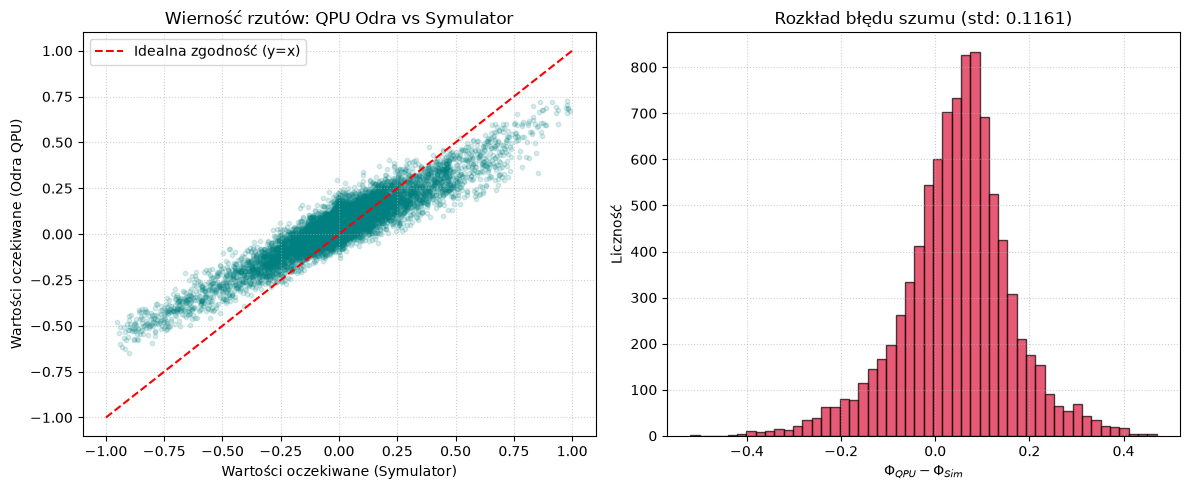

In [56]:
import numpy as np
import matplotlib.pyplot as plt

Phi_odra = np.load("phi_odra_wig_banki.npy")

plt.figure(figsize=(12, 5))

# 1. Korelacja cech (Scatter)
plt.subplot(1, 2, 1)
plt.scatter(Phi_sim.flatten(), Phi_odra.flatten(), alpha=0.15, color="teal", s=10)
plt.plot([-1, 1], [-1, 1], "r--", linewidth=1.5, label="Idealna zgodność (y=x)")
plt.title("Wierność rzutów: QPU Odra vs Symulator")
plt.xlabel("Wartości oczekiwane (Symulator)")
plt.ylabel("Wartości oczekiwane (Odra QPU)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

# 2. Histogram różnic (błąd szumu sprzętowego)
plt.subplot(1, 2, 2)
errors = (Phi_odra - Phi_sim).flatten()
plt.hist(errors, bins=50, color="crimson", alpha=0.7, edgecolor="black")
plt.title(f"Rozkład błędu szumu (std: {np.std(errors):.4f})")
plt.xlabel(r"$\Phi_{QPU} - \Phi_{Sim}$")
plt.ylabel("Liczność")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()